Loading Landsat and RGI Glacier Polygons :)
Fetching and stitching Copernicus DEM tiles...
Elevation map merged from 18 tiles.
Analyzing 761 glaciers. Processing...

 SUCCESS! Regional Mean ELA: 1462.44 meters
 Data for 484 glaciers saved to 'GlacierBay_ELA_Final_Results.csv'


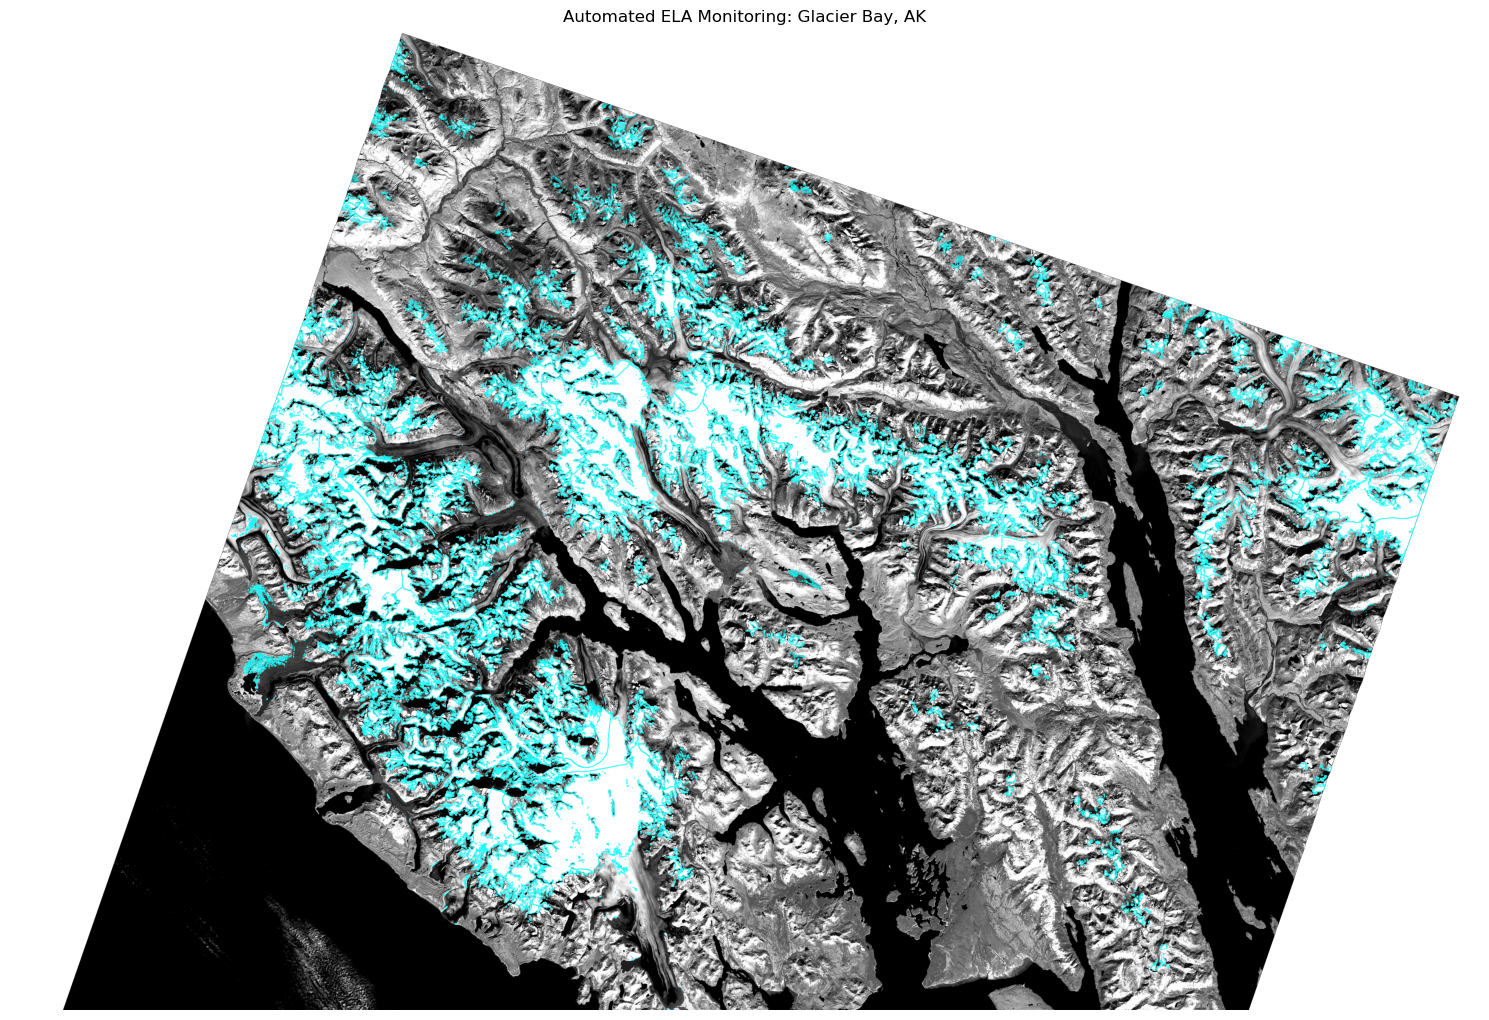

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
import rioxarray.merge
import geopandas as gpd
import pystac_client
import planetary_computer
from pyproj import Transformer
from skimage.filters import threshold_otsu
from skimage import measure
import pandas as pd
import warnings
import os

warnings.filterwarnings('ignore', category=RuntimeWarning)

B5_FILE = r"C:\Users\jaely\OneDrive\Documents\AES408final\LC08_L2SP_059019_20250901_20250911_02_T1\LC08_L2SP_059019_20250901_20250911_02_T1_SR_B5.TIF" 
RGI_PATH = r"C:\Users\jaely\OneDrive\Documents\AES408final\RGI2000-v7.0-G-01_alaska\RGI2000-v7.0-G-01_alaska.shp" # Use the "G" file for glacier outlines


def load_and_scale(path):
    """Scaling Landsat 8 L2SP DN to Surface Reflectance: $SR = (DN \times 0.0000275) - 0.2$"""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    ds = rioxarray.open_rasterio(path).squeeze()
    return ds.where(ds > 0) * 0.0000275 - 0.2

print("Loading Landsat and RGI Glacier Polygons :)")
ref5 = load_and_scale(B5_FILE)
glaciers_gdf = gpd.read_file(RGI_PATH).to_crs(ref5.rio.crs)

left, bottom, right, top = ref5.rio.bounds()
subset = glaciers_gdf.cx[left:right, bottom:top].copy()

area_col = 'area_km2' if 'area_km2' in subset.columns else 'Area'
subset = subset[subset[area_col] > 1.0]
subset = subset[subset.is_valid & ~subset.is_empty]

total_bounds = subset.total_bounds
ref5_clipped = ref5.rio.clip_box(*total_bounds)

use_dem = False
try:
    print("Fetching and stitching Copernicus DEM tiles...")
    transformer = Transformer.from_crs("epsg:32608", "epsg:4326", always_xy=True)
    lon_min, lat_min = transformer.transform(total_bounds[0], total_bounds[1])
    lon_max, lat_max = transformer.transform(total_bounds[2], total_bounds[3])

    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1", 
        modifier=planetary_computer.sign_inplace
    )
    search = catalog.search(collections=["cop-dem-glo-30"], bbox=[lon_min, lat_min, lon_max, lat_max])
    items = search.item_collection()
    
    if len(items) > 0:
        dem_list = [rioxarray.open_rasterio(item.assets["data"].href) for item in items]
        dem_merged = rioxarray.merge.merge_arrays(dem_list)
        dem_matched = dem_merged.rio.reproject_match(ref5_clipped).squeeze()
        use_dem = True
        print(f"Elevation map merged from {len(items)} tiles.")
    else:
        print(" No DEM tiles found for this specific area.")
except Exception as e:
    print(f"DEM Error: {e}. Results will map outlines but lack altitude.")


fig, ax = plt.subplots(figsize=(15, 12))
img_extent = [ref5_clipped.x.min(), ref5_clipped.x.max(), ref5_clipped.y.min(), ref5_clipped.y.max()]
ax.imshow(ref5_clipped.values, cmap='gray', extent=img_extent, origin='upper', vmin=0, vmax=0.4)

export_data = [] 
print(f"Analyzing {len(subset)} glaciers. Processing...")

for i, glacier in subset.iterrows():
    try:
       
        g_ref5 = ref5_clipped.rio.clip([glacier.geometry])
        vals = g_ref5.values.flatten()
        valid = vals[(~np.isnan(vals)) & (vals > 0.001)]
        
        if len(valid) < 100: continue
        thresh = threshold_otsu(valid)
    
        avg_alt = np.nan
        if use_dem:
            g_dem = dem_matched.rio.clip([glacier.geometry])
            acc_mask = (g_ref5 > thresh)
            if acc_mask.any() and not np.all(np.isnan(g_dem.where(acc_mask).values)):
                avg_alt = np.nanmean(g_dem.where(acc_mask).values)

        export_data.append({
            'Glacier_ID': glacier.get('rgi_id', i),
            'Area_km2': round(glacier.get(area_col, 0), 2),
            'ELA_Altitude_m': round(avg_alt, 2) if not np.isnan(avg_alt) else "NaN"
        })

        clean_patch = np.nan_to_num(g_ref5.values, nan=0.0)
        contours = measure.find_contours(clean_patch, thresh)
        for contour in contours:
            rows = np.clip(contour[:, 0].astype(int), 0, g_ref5.shape[0] - 1)
            cols = np.clip(contour[:, 1].astype(int), 0, g_ref5.shape[1] - 1)
            ax.plot(g_ref5.x.values[cols], g_ref5.y.values[rows], color='cyan', lw=0.7, alpha=0.5)

    except Exception:
        continue

if export_data:
    df = pd.DataFrame(export_data)
    df.to_csv("GlacierBay_ELA_Final_Results.csv", index=False)
    valid_altitudes = df[df['ELA_Altitude_m'] != "NaN"]['ELA_Altitude_m'].astype(float)
    if not valid_altitudes.empty:
        print(f"\n SUCCESS! Regional Mean ELA: {valid_altitudes.mean():.2f} meters")
    print(f" Data for {len(df)} glaciers saved to 'GlacierBay_ELA_Final_Results.csv'")

ax.set_title(f"Automated ELA Monitoring: Glacier Bay, AK")
ax.set_axis_off()
plt.tight_layout()
plt.show()